In [51]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)

In [52]:
DATA_PATH = "talabat_enhanced_orders2.csv"  # ensure the file is in the same folder as this notebook
df = pd.read_csv(DATA_PATH)

df.head(10)

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
0,56795,U4934,991,313,Sushi,5,305.65,2025-06-11 14:37:00,2025-06-11 14:58:00,21,Giza,Wallet,Delivered,Car,30.011739,31.220610,30.019520,31.196654,30.026240,31.200332,2.466822,Medium,Online
1,81167,U8701,151,316,Pizza,4,446.40,2025-06-08 20:13:00,2025-06-08 20:49:00,36,Cairo,Cash,In Transit,Car,30.045413,31.223939,30.062724,31.220663,30.050536,31.237185,1.944823,Low,Online
2,75889,U7689,138,363,Koshary,3,394.50,2025-06-07 03:29:00,2025-06-07 04:20:00,51,Mansoura,Credit Card,Delivered,Car,31.057534,31.366192,31.045638,31.373109,31.020001,31.399328,1.475038,Low,Online
3,34786,U7076,540,258,Burger,4,139.20,2025-06-09 20:49:00,2025-06-09 21:30:00,41,Tanta,Wallet,Cancelled,Bicycle,30.787492,30.993809,30.789228,30.984042,30.805722,30.997262,0.954482,Low,Online
4,38475,U6245,847,110,Salad,2,207.02,2025-06-08 12:05:00,2025-06-08 12:33:00,28,Tanta,Credit Card,Cancelled,Bicycle,30.803427,30.983386,30.768538,30.992124,30.792271,30.987854,3.957460,Medium,Online
5,88329,U3379,454,90,Sandwich,1,125.68,2025-06-02 04:02:00,2025-06-02 04:33:00,31,Alexandria,Cash,Delivered,Car,31.180300,29.922967,31.180552,29.899449,31.211355,29.929651,2.242070,Low,Online
6,79499,U3029,168,479,Sushi,2,243.62,2025-06-15 01:06:00,2025-06-15 01:59:00,53,Giza,Credit Card,Delivered,Motorbike,30.013826,31.215348,30.020233,31.228303,29.995995,31.212204,1.437552,Low,Online
7,27325,U3674,473,321,Fried Chicken,1,149.87,2025-06-04 01:02:00,2025-06-04 01:53:00,51,Tanta,Cash,Cancelled,Car,30.794454,30.998586,30.791487,31.002607,30.799764,31.006845,0.506267,Low,Online
8,73621,U8696,704,42,Pasta,4,562.32,2025-06-14 06:45:00,2025-06-14 07:33:00,48,Zagazig,Credit Card,Delivered,Car,30.573653,31.508104,30.602105,31.519432,30.587649,31.500689,3.336044,Low,Online
9,18180,U3260,458,183,Pasta,5,194.95,2025-06-03 02:50:00,2025-06-03 03:15:00,25,Alexandria,Cash,Delivered,Motorbike,31.193297,29.906175,31.187237,29.913781,31.202042,29.926440,0.988472,Low,Online


In [53]:
print("Shape:", df.shape)
print("\nMissing values per column:")
display(df.isna().sum().to_frame("missing_count").T)

print("\nDuplicate rows:", df.duplicated().sum())

Shape: (25000, 23)

Missing values per column:


,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,Delivery_Time,Delivery_Duration_Minutes,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability
missing_count,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



Duplicate rows: 0


In [54]:
target_col = "Order_Status"
df[target_col].value_counts()

,count
Order_Status,
Delivered,10197
Cancelled,9812
In Transit,4991


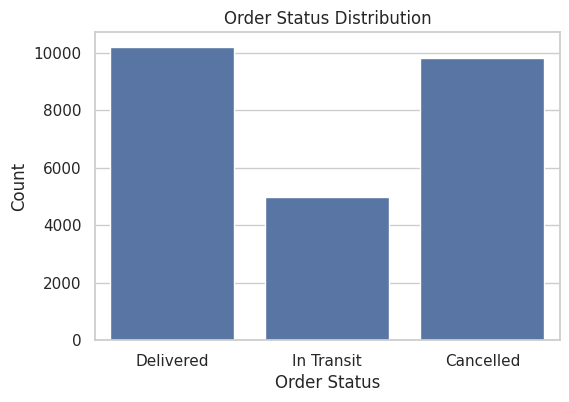

In [55]:
plt.figure(figsize=(6,4))
sns.countplot(x=target_col, data=df)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.show()

In [56]:
df.dtypes

,0
Order_ID,int64
User_ID,object
Restaurant_ID,int64
Driver_ID,int64
Item_Name,object
Quantity,int64
Total_Price,float64
Order_Time,object
Delivery_Time,object
Delivery_Duration_Minutes,int64


In [57]:
drop_cols = ["Delivery_Time", "Delivery_Duration_Minutes"]

# keep only existing columns
drop_cols = [c for c in drop_cols if c in df.columns]

# drop from dataframe
df = df.drop(columns=drop_cols)

In [58]:
df_fe = df.copy()

# Parse time columns
df_fe["Order_Time"] = pd.to_datetime(df_fe["Order_Time"], errors="coerce")

df_fe["order_hour"] = df_fe["Order_Time"].dt.hour
df_fe["order_dayofweek"] = df_fe["Order_Time"].dt.dayofweek  # Monday=0, Sunday=6
df_fe["is_weekend"] = df_fe["order_dayofweek"].isin([5,6]).astype(int)

# Simple peak-hour rule (you can adjust based on local context):
# Lunch: 12-15, Dinner: 19-23
df_fe["is_peak_hour"] = df_fe["order_hour"].isin(list(range(12,16)) + list(range(19,24))).astype(int)

df_fe[["Order_Time","order_hour","order_dayofweek","is_weekend","is_peak_hour"]].head(10)

,Order_Time,order_hour,order_dayofweek,is_weekend,is_peak_hour
0,2025-06-11 14:37:00,14,2,0,1
1,2025-06-08 20:13:00,20,6,1,1
2,2025-06-07 03:29:00,3,5,1,0
3,2025-06-09 20:49:00,20,0,0,1
4,2025-06-08 12:05:00,12,6,1,1
5,2025-06-02 04:02:00,4,0,0,0
6,2025-06-15 01:06:00,1,6,1,0
7,2025-06-04 01:02:00,1,2,0,0
8,2025-06-14 06:45:00,6,5,1,0
9,2025-06-03 02:50:00,2,1,0,0


In [59]:
df_fe["price_per_item"] = df_fe["Total_Price"] / df_fe["Quantity"]
df_fe[["Quantity","Total_Price","price_per_item"]].head(10)

,Quantity,Total_Price,price_per_item
0,5,305.65,61.13
1,4,446.40,111.60
2,3,394.50,131.50
3,4,139.20,34.80
4,2,207.02,103.51
5,1,125.68,125.68
6,2,243.62,121.81
7,1,149.87,149.87
8,4,562.32,140.58
9,5,194.95,38.99


In [60]:
def haversine_km(lat1, lon1, lat2, lon2):
    """Vectorized Haversine distance in kilometers."""
    R = 6371.0
    lat1 = np.radians(lat1); lon1 = np.radians(lon1)
    lat2 = np.radians(lat2); lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

coord_cols = {"Restaurant_Lat","Restaurant_Lon","Customer_Lat","Customer_Lon"}
if coord_cols.issubset(set(df_fe.columns)):
    df_fe["haversine_rest_to_cust_km"] = haversine_km(
        df_fe["Restaurant_Lat"], df_fe["Restaurant_Lon"],
        df_fe["Customer_Lat"], df_fe["Customer_Lon"]
    )
    display(df_fe[["Delivery_Distance_km","haversine_rest_to_cust_km"]].head(10))
else:
    print("Coordinate columns not found. Skipping Haversine feature.")

,Delivery_Distance_km,haversine_rest_to_cust_km
0,2.466822,2.463521
1,1.944823,1.950558
2,1.475038,1.477900
3,0.954482,0.952771
4,3.957460,3.968334
5,2.242070,2.237553
6,1.437552,1.436513
7,0.506267,0.506320
8,3.336044,3.344290
9,0.988472,0.988730


In [61]:
df['Item_Name'].unique()

array(['Sushi', 'Pizza', 'Koshary', 'Burger', 'Salad', 'Sandwich',
       'Fried Chicken', 'Pasta', 'Shawarma'], dtype=object)

In [75]:
if "Item_Name" in df_fe.columns:
    top_k =11
    top_items = df_fe["Item_Name"].value_counts().head(top_k).index
    df_fe["Item_Name_reduced"] = np.where(df_fe["Item_Name"].isin(top_items), df_fe["Item_Name"], "Other")
    print("Unique Item_Name:", df_fe["Item_Name"].nunique())
    print("Unique Item_Name_reduced:", df_fe["Item_Name_reduced"].nunique())
    df_fe[["Item_Name","Item_Name_reduced"]].head(10)
else:
    print("Item_Name column not found.")

Unique Item_Name: 9
Unique Item_Name_reduced: 9


In [63]:
df_fe["price_tier"] = pd.cut(
    df_fe["Total_Price"],
    bins=[0, 100, 250, 500, np.inf],
    labels=["low","medium","high","very_high"]
)

df_fe[["Total_Price","price_tier"]].head(10)

,Total_Price,price_tier
0,305.65,high
1,446.40,high
2,394.50,high
3,139.20,medium
4,207.02,medium
5,125.68,medium
6,243.62,medium
7,149.87,medium
8,562.32,very_high
9,194.95,medium


In [64]:
df_fe.head()

,Order_ID,User_ID,Restaurant_ID,Driver_ID,Item_Name,Quantity,Total_Price,Order_Time,City,Payment_Method,Order_Status,Driver_Vehicle,Restaurant_Lat,Restaurant_Lon,Customer_Lat,Customer_Lon,Driver_Lat,Driver_Lon,Delivery_Distance_km,Traffic_Level,Driver_Availability,order_hour,order_dayofweek,is_weekend,is_peak_hour,price_per_item,haversine_rest_to_cust_km,Item_Name_reduced,price_tier
0,56795,U4934,991,313,Sushi,5,305.65,2025-06-11 14:37:00,Giza,Wallet,Delivered,Car,30.011739,31.220610,30.019520,31.196654,30.026240,31.200332,2.466822,Medium,Online,14,2,0,1,61.13,2.463521,Other,high
1,81167,U8701,151,316,Pizza,4,446.40,2025-06-08 20:13:00,Cairo,Cash,In Transit,Car,30.045413,31.223939,30.062724,31.220663,30.050536,31.237185,1.944823,Low,Online,20,6,1,1,111.60,1.950558,Pizza,high
2,75889,U7689,138,363,Koshary,3,394.50,2025-06-07 03:29:00,Mansoura,Credit Card,Delivered,Car,31.057534,31.366192,31.045638,31.373109,31.020001,31.399328,1.475038,Low,Online,3,5,1,0,131.50,1.477900,Koshary,high
3,34786,U7076,540,258,Burger,4,139.20,2025-06-09 20:49:00,Tanta,Wallet,Cancelled,Bicycle,30.787492,30.993809,30.789228,30.984042,30.805722,30.997262,0.954482,Low,Online,20,0,0,1,34.80,0.952771,Burger,medium
4,38475,U6245,847,110,Salad,2,207.02,2025-06-08 12:05:00,Tanta,Credit Card,Cancelled,Bicycle,30.803427,30.983386,30.768538,30.992124,30.792271,30.987854,3.957460,Medium,Online,12,6,1,1,103.51,3.968334,Other,medium


In [65]:
drop_cols = [
    "Order_ID", "User_ID", "Restaurant_ID", "Driver_ID","Total_Price","haversine_rest_to_cust_km",
    "Order_Time","Item_Name"  # we replaced it with Item_Name_reduced
]

# keep only columns that exist (safe for future versions of the dataset)
drop_cols = [c for c in drop_cols if c in df_fe.columns]

X = df_fe.drop(columns=drop_cols + [target_col])
y = df_fe[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (25000, 20)
y shape: (25000,)


In [66]:
X.columns

Index(['Quantity', 'City', 'Payment_Method', 'Driver_Vehicle',
       'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon',
       'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'Traffic_Level',
       'Driver_Availability', 'order_hour', 'order_dayofweek', 'is_weekend',
       'is_peak_hour', 'price_per_item', 'Item_Name_reduced', 'price_tier'],
      dtype='object')

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (20000, 20)
Test size: (5000, 20)


In [68]:
# Identify categorical and numerical columns automatically
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X_train.select_dtypes(include=[np.number, "bool"]).columns.tolist()


print("Categorical columns:\n", categorical_cols,'\n')
print("Numeric columns:\n", numeric_cols)

preprocess = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ("num", "passthrough", numeric_cols),
    ]
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    class_weight=None
)

model = Pipeline(steps=[
    ("preprocess", preprocess),
    ("rf", rf)
])

model

Categorical columns:
 ['City', 'Payment_Method', 'Driver_Vehicle', 'Traffic_Level', 'Driver_Availability', 'Item_Name_reduced', 'price_tier'] 

Numeric columns:
 ['Quantity', 'Restaurant_Lat', 'Restaurant_Lon', 'Customer_Lat', 'Customer_Lon', 'Driver_Lat', 'Driver_Lon', 'Delivery_Distance_km', 'order_hour', 'order_dayofweek', 'is_weekend', 'is_peak_hour', 'price_per_item']


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['City', 'Payment_Method',
                                                   'Driver_Vehicle',
                                                   'Traffic_Level',
                                                   'Driver_Availability',
                                                   'Item_Name_reduced',
                                                   'price_tier']),
                                                 ('num', 'passthrough',
                                                  ['Quantity', 'Restaurant_Lat',
                                                   'Restaurant_Lon',
                                                   'Customer_Lat',
                                                   'Customer_Lon', 'Driver_Lat',
                                                   'Driver_Lon',
                                                   'Delivery_Distance_km',
                                                   'order_hour',
                                                   'order_dayofweek',
                                                   'is_weekend', 'is_peak_hour',
                                                   'price_per_item'])])),
                ('rf',
                 RandomForestClassifier(n_estimators=300, n_jobs=-1,
                                        random_state=42))])

In [69]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.4008

Classification Report:
              precision    recall  f1-score   support

   Cancelled       0.39      0.46      0.42      1963
   Delivered       0.41      0.54      0.46      2039
  In Transit       0.10      0.00      0.00       998

    accuracy                           0.40      5000
   macro avg       0.30      0.33      0.30      5000
weighted avg       0.34      0.40      0.36      5000



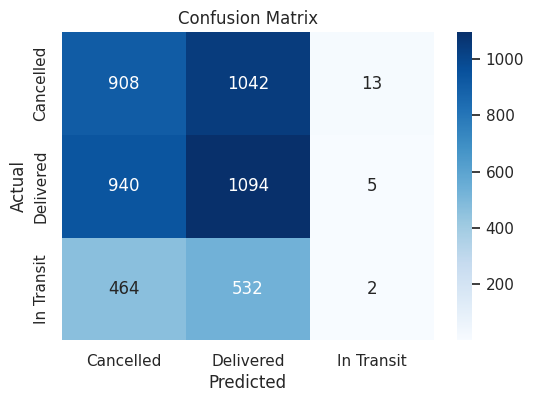

In [70]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [71]:
# Get feature names after preprocessing
ohe = model.named_steps["preprocess"].named_transformers_["cat"]
cat_feature_names = ohe.get_feature_names_out(categorical_cols) if len(categorical_cols) > 0 else np.array([])
all_feature_names = np.concatenate([cat_feature_names, np.array(numeric_cols)])

importances = model.named_steps["rf"].feature_importances_

fi = (pd.DataFrame({"feature": all_feature_names, "importance": importances})
        .sort_values("importance", ascending=False))

fi.head(15)

,feature,importance
38,price_per_item,0.084617
33,Delivery_Distance_km,0.084054
30,Customer_Lon,0.082394
31,Driver_Lat,0.082239
32,Driver_Lon,0.082081
27,Restaurant_Lat,0.081720
29,Customer_Lat,0.081719
28,Restaurant_Lon,0.081447
34,order_hour,0.057204
35,order_dayofweek,0.041031


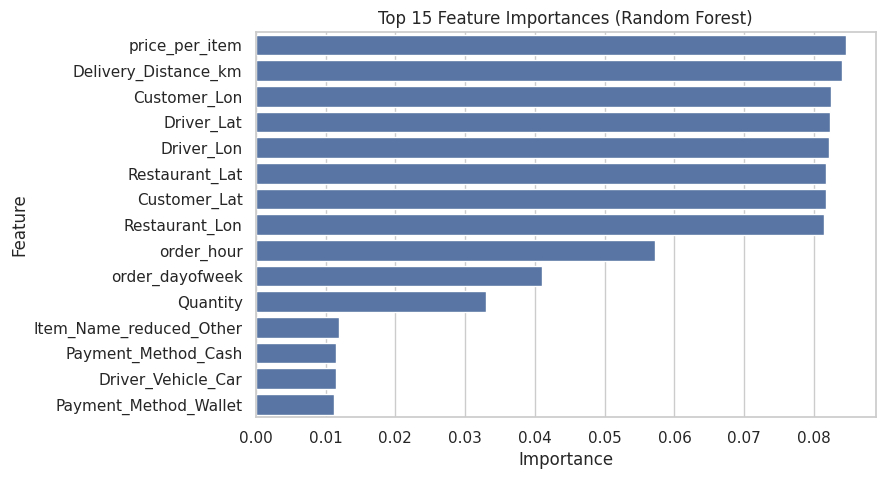

In [72]:
plt.figure(figsize=(8,5))
top_n = 15
sns.barplot(data=fi.head(top_n), x="importance", y="feature")
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()